In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from scipy import stats

 ANÁLISIS DE MUTACIÓN CLIMÁTICA (PCA + HDBSCAN)

In [2]:
df_hist = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/data_hist.parquet")
df_future = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/fut_clean.parquet")

In [11]:


# ANÁLISIS DE MUTACIÓN CLIMÁTICA (SSP5-8.5)...")

# 1. MAPEO EXPLÍCITO Y CÁLCULO DE DELTAS

# Agrupamos histórico (asumiendo que tus columnas se llaman tmax, tmin, ppt)
hist_agg = df_hist.group_by("location").agg([
    pl.col("tmax").mean().alias("tmax_hist"),
    pl.col("tmin").mean().alias("tmin_hist"),
    pl.col("ppt").mean().alias("ppt_hist") 
])

# Agrupamos futuro seleccionando solo el escenario 585
fut_agg = df_future.group_by("location").agg([
    pl.col("tmax_585").mean().alias("tmax_fut"),
    pl.col("tmin_585").mean().alias("tmin_fut"),
    pl.col("pr_585").mean().alias("ppt_fut") # Ojo al cambio de 'pr' a 'ppt'
])

# Cruzamos y calculamos el Delta matemático (Futuro - Histórico)
df_deltas = (
    hist_agg.join(fut_agg, on="location", how="inner")
    .with_columns([
        (pl.col("tmax_fut") - pl.col("tmax_hist")).alias("delta_tmax"),
        (pl.col("tmin_fut") - pl.col("tmin_hist")).alias("delta_tmin"),
        (pl.col("ppt_fut") - pl.col("ppt_hist")).alias("delta_ppt")
    ])
    .drop_nulls()  # Ahora sí, la guillotina será suave
)

print(f"Matriz de mutación lista. Parcelas a analizar: {df_deltas.shape[0]:,}")


Matriz de mutación lista. Parcelas a analizar: 32,931


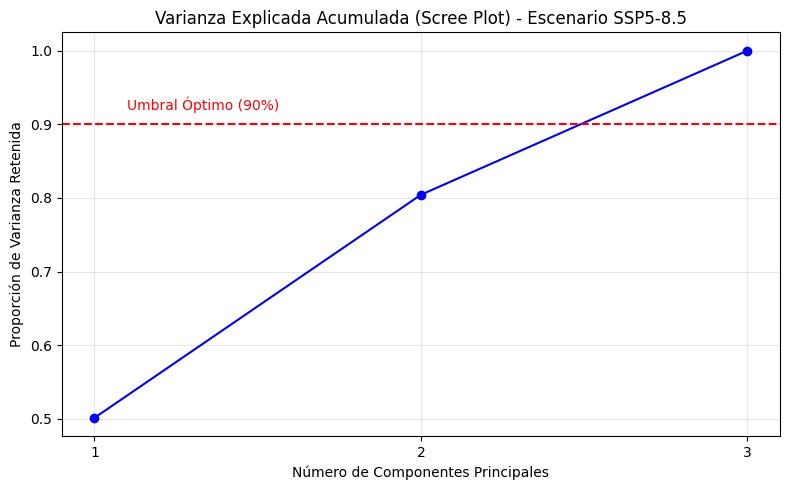


Análisis de Varianza:
   -> Con 1 componentes retenemos el 50.12% de la mutación climática.
   -> Con 2 componentes retenemos el 80.42% de la mutación climática.
   -> Con 3 componentes retenemos el 100.00% de la mutación climática.


In [12]:
# 2. EVALUACIÓN DE COMPONENTES (PCA)
# Estandarizando varianzas y evaluando componentes PCA...")
X_deltas = df_deltas.select(["delta_tmax", "delta_tmin", "delta_ppt"]).to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_deltas)

pca_eval = PCA(random_state=42)
pca_eval.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_eval.explained_variance_ratio_)

# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='-', color='b')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.text(1.1, 0.92, 'Umbral Óptimo (90%)', color='red', fontsize=10)
plt.title('Varianza Explicada Acumulada (Scree Plot) - Escenario SSP5-8.5')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Retenida')
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAnálisis de Varianza:")
for i, var in enumerate(varianza_acumulada):
    print(f"   -> Con {i+1} componentes retenemos el {var*100:.2f}% de la mutación climática.")

In [13]:
# Escaneando densidades espaciales con HDBSCAN (2D)...")

# Entrenamos el PCA definitivo limitándolo a 2 dimensiones
pca_final = PCA(n_components=2, random_state=42)
X_pca_final = pca_final.fit_transform(X_scaled)

# Ejecutamos HDBSCAN
# min_cluster_size=100 fuerza agrupaciones significativas (zonas agrícolas grandes)
hdbscan = HDBSCAN(min_cluster_size=100, metric='euclidean')
clusters = hdbscan.fit_predict(X_pca_final)

# Guardamos los resultados de vuelta en Polars
df_deltas = df_deltas.with_columns([
    pl.Series("PCA1", X_pca_final[:, 0]),
    pl.Series("PCA2", X_pca_final[:, 1]),
    pl.Series("Cluster_Mutacion", clusters)
])


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


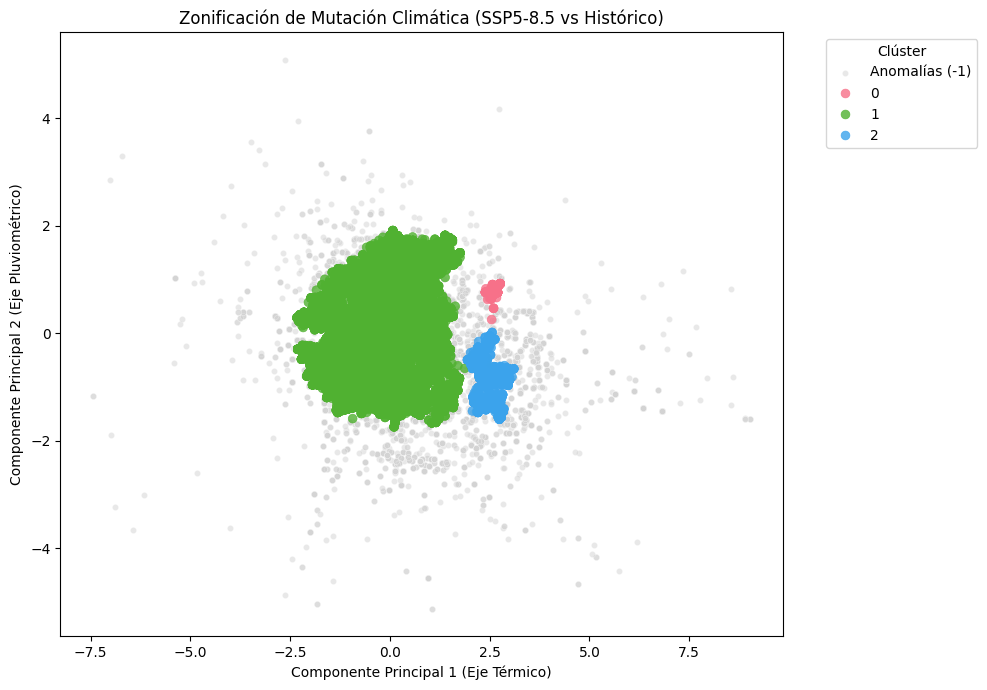

In [14]:
# 4. VISUALIZACIÓN DEL ESPACIO DE MUTACIÓN
plt.figure(figsize=(10, 7))

# Filtramos colores: el -1 es "Ruido/Anomalías" y lo pintaremos de gris
unique_clusters = np.unique(clusters)
n_clusters = len(unique_clusters[unique_clusters != -1])
palette = sns.color_palette("husl", n_clusters)

# Dibujamos primero el ruido (gris) para que quede al fondo
sns.scatterplot(
    data=df_deltas.filter(pl.col("Cluster_Mutacion") == -1).to_pandas(), 
    x="PCA1", y="PCA2", color="lightgray", alpha=0.5, s=20, label="Anomalías (-1)"
)

# Dibujamos los clústeres principales
sns.scatterplot(
    data=df_deltas.filter(pl.col("Cluster_Mutacion") != -1).to_pandas(), 
    x="PCA1", y="PCA2", hue="Cluster_Mutacion", palette=palette, alpha=0.8, s=40, edgecolor=None
)

plt.title("Zonificación de Mutación Climática (SSP5-8.5 vs Histórico)")
plt.xlabel("Componente Principal 1 (Eje Térmico)")
plt.ylabel("Componente Principal 2 (Eje Pluviométrico)")
plt.legend(title="Clúster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("hdbscan_clusters.png", dpi=300)
plt.show()


In [15]:
# 5. PERFILADO DE LOS CLÚSTERES
print("\n PERFIL BIOFÍSICO DE LOS CLÚSTERES (Promedios del Delta):")
perfil_clusters = (
    df_deltas.group_by("Cluster_Mutacion")
    .agg([
        pl.len().alias("Numero_Parcelas"),
        pl.col("delta_tmax").mean().round(2).alias("Δ Tmax (°C)"),
        pl.col("delta_tmin").mean().round(2).alias("Δ Tmin (°C)"),
        pl.col("delta_ppt").mean().round(2).alias("Δ Precip (mm)")
    ])
    .sort("Cluster_Mutacion")
)
display(perfil_clusters)


 PERFIL BIOFÍSICO DE LOS CLÚSTERES (Promedios del Delta):


Cluster_Mutacion,Numero_Parcelas,Δ Tmax (°C),Δ Tmin (°C),Δ Precip (mm)
i64,u32,f64,f64,f64
-1,2646,-0.15,0.75,127.41
0,124,0.86,-0.81,219.4
1,29204,1.48,1.6,53.74
2,957,-0.72,-0.02,190.33


VALIDACIÓN ESTADÍSTICA DEL MODELO HDBSCAN.

Confianza media de asignación del modelo: 98.44%


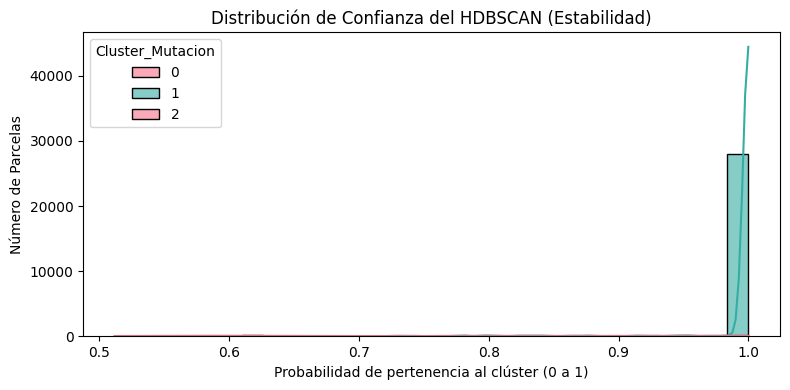

In [17]:
# 1. VALIDACIÓN INTERNA: PROBABILIDADES DE ASIGNACIÓN
# HDBSCAN calcula qué tan "seguro" está de que una parcela pertenezca a su clúster
probabilidades = hdbscan.probabilities_

# Actualizamos nuestro DataFrame con esta nueva métrica
df_deltas = df_deltas.with_columns(
    pl.Series("Probabilidad_Confianza", probabilidades)
)

# Filtramos el ruido (-1) porque por definición su probabilidad es 0
df_validos = df_deltas.filter(pl.col("Cluster_Mutacion") != -1)

# Calculamos el promedio de confianza general
confianza_media = df_validos.select(pl.col("Probabilidad_Confianza").mean()).item()
print(f"Confianza media de asignación del modelo: {confianza_media * 100:.2f}%")

# Gráfico de distribución de confianza
plt.figure(figsize=(8, 4))
sns.histplot(data=df_validos.to_pandas(), x="Probabilidad_Confianza", hue="Cluster_Mutacion", 
             kde=True, palette="husl", bins=30, alpha=0.6)
plt.title("Distribución de Confianza del HDBSCAN (Estabilidad)")
plt.xlabel("Probabilidad de pertenencia al clúster (0 a 1)")
plt.ylabel("Número de Parcelas")
plt.tight_layout()
plt.savefig("hdbscan_confianza.png", dpi=300)
plt.show()





 VALIDACIÓN DE SEPARACIÓN (Test H de Kruskal-Wallis)
Estadístico H: 2728.28
P-Valor: 0.0000e+00
   -> CONCLUSIÓN: El test es SIGNIFICATIVO. Los clústeres descubiertos representan zonas climáticas estadísticamente diferentes. El agrupamiento es válido.


C:\Users\lesli\AppData\Local\Temp\ipykernel_19068\2515964016.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_validos.to_pandas(), x="Cluster_Mutacion", y="delta_tmax", palette="husl")


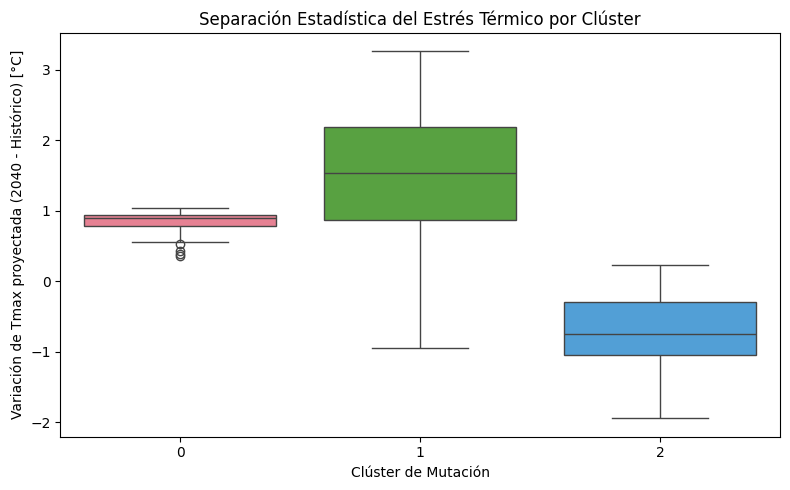

In [19]:
# 2. VALIDACIÓN EXTERNA: SEPARACIÓN ESTADÍSTICA (KRUSKAL-WALLIS)
# Queremos demostrar que los clústeres son matemáticamente diferentes entre sí.
# Usamos Kruskal-Wallis porque es un test no paramétrico (no asume distribución normal).

print("\n VALIDACIÓN DE SEPARACIÓN (Test H de Kruskal-Wallis)")
# Separamos los datos de Tmax (o cualquier variable de interés) por clúster
grupos_tmax = []
for c in df_validos["Cluster_Mutacion"].unique().to_list():
    grupo = df_validos.filter(pl.col("Cluster_Mutacion") == c)["delta_tmax"].to_numpy()
    grupos_tmax.append(grupo)

# Ejecutamos el test
stat, p_valor = stats.kruskal(*grupos_tmax)

print(f"Estadístico H: {stat:.2f}")
print(f"P-Valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("   -> CONCLUSIÓN: El test es SIGNIFICATIVO. Los clústeres descubiertos representan zonas climáticas estadísticamente diferentes. El agrupamiento es válido.")
else:
    print("   -> CONCLUSIÓN: El test NO es significativo. Los clústeres podrían ser fruto del azar.")

# Visualización de la separación estadística
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_validos.to_pandas(), x="Cluster_Mutacion", y="delta_tmax", palette="husl")
plt.title("Separación Estadística del Estrés Térmico por Clúster")
plt.xlabel("Clúster de Mutación")
plt.ylabel("Variación de Tmax proyectada (2040 - Histórico) [°C]")
plt.tight_layout()
plt.savefig("hdbscan_separacion.png", dpi=300)
plt.show()